# Finite Element Method in 1D

The **Finite Element Method (FEM)** is one of the most widely used numerical techniques for solving partial differential equations. It is the backbone of structural analysis, fluid dynamics, electromagnetics, and many other fields.

**Problem.** We solve the one-dimensional Poisson equation
$$
-u''(x) = f(x), \quad x \in (0,1), \qquad u(0) = u(1) = 0,
$$
with a right-hand side featuring two frequency components:
$$
f(x) = \pi^2 \sin(\pi x) + 4\pi^2 \sin(2\pi x).
$$
The exact solution is
$$
u_{\mathrm{true}}(x) = \sin(\pi x) + \sin(2\pi x),
$$
which satisfies $-u'' = f$ and vanishes at both endpoints (since $\sin(k\pi \cdot 0)=0$ and $\sin(k\pi \cdot 1)=0$ for integer $k$).

**Why FEM?** The key idea is the **weak form**: multiply by a test function $v$ and integrate by parts,
$$
\int_0^1 u'(x)v'(x)\,dx = \int_0^1 f(x)v(x)\,dx \quad \forall v \in H^1_0(0,1).
$$
By restricting $u$ and $v$ to a **finite-dimensional piecewise-linear space** spanned by hat functions $\{\phi_i\}$, this becomes a linear system $K\mathbf{u} = \mathbf{b}$, where $K_{ij} = \int \phi_i'\phi_j'\,dx$ is the **stiffness matrix** and $b_i = \int f\phi_i\,dx$ is the **load vector**.

**What we demonstrate.** We run six mesh refinement levels $n \in \{16, 24, 36, 52, 74, 104\}$ and observe the expected $O(h^2)$ convergence of the maximum error.

## Setup: right-hand side and exact solution

We define the two-frequency right-hand side and the corresponding closed-form solution. The multi-frequency nature makes the convergence study more interesting than a single-mode example: the FEM must resolve both the slow ($k=1$) and the fast ($k=2$) oscillation.

Text(0.5, 0.98, 'Problem data')

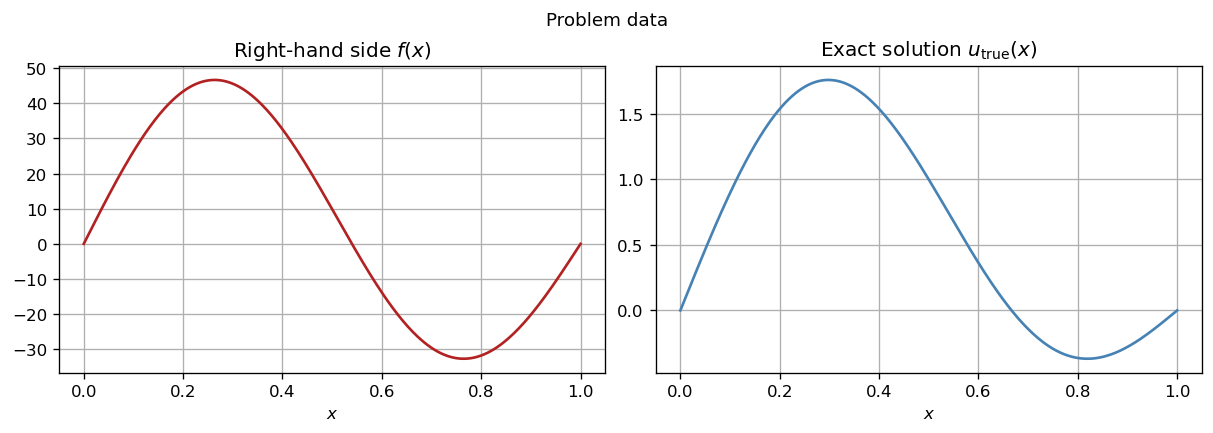

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUT = Path("python/fem-1d-2d")
OUT.mkdir(parents=True, exist_ok=True)

# RHS: f(x) = pi^2 sin(pi x) + 4 pi^2 sin(2 pi x)
f = lambda x: np.pi**2 * np.sin(np.pi * x) + 4 * np.pi**2 * np.sin(2 * np.pi * x)

# Exact solution: u_true(x) = sin(pi x) + sin(2 pi x)
u_true = lambda x: np.sin(np.pi * x) + np.sin(2 * np.pi * x)

# Quick sanity check: evaluate at interior points
xx = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(xx, f(xx), color="firebrick", lw=1.6)
axes[0].set_title("Right-hand side $f(x)$")
axes[0].set_xlabel("$x$")
axes[1].plot(xx, u_true(xx), color="steelblue", lw=1.6)
axes[1].set_title("Exact solution $u_{\\mathrm{true}}(x)$")
axes[1].set_xlabel("$x$")
plt.suptitle("Problem data", fontsize=11)

## Assembly and solve for multiple mesh sizes

For a uniform mesh with $n$ elements (mesh size $h = 1/n$) on $(0,1)$, the interior nodes are $\{x_1, \ldots, x_{n-1}\}$. The local stiffness matrix for each element $[x_e, x_{e+1}]$ is
$$
K^e = \frac{1}{h}\begin{pmatrix}1 & -1 \\ -1 & 1\end{pmatrix},
$$
and the local load vector (midpoint quadrature) is
$$
b^e = \frac{h}{2}\begin{pmatrix}f(x_e) \\ f(x_{e+1})\end{pmatrix} \approx f\!\left(\tfrac{x_e+x_{e+1}}{2}\right)\frac{h}{2}\begin{pmatrix}1\\ 1\end{pmatrix}.
$$
After assembling and enforcing Dirichlet boundary conditions, we solve the $(n-1)\times(n-1)$ system $K\mathbf{u} = \mathbf{b}$.

In [2]:
levels = [16, 24, 36, 52, 74, 104]
sol = []
errs = []

for n in levels:
    x = np.linspace(0, 1, n + 1)
    h = x[1] - x[0]
    N = n - 1   # number of interior nodes

    K = np.zeros((N, N))
    b = np.zeros(N)

    for e in range(n):
        xL, xR = x[e], x[e + 1]
        Ke = (1 / h) * np.array([[1, -1], [-1, 1]])
        xm = 0.5 * (xL + xR)
        fe = f(xm) * h * 0.5 * np.array([1.0, 1.0])
        idx = [e - 1, e]   # interior indices (boundary nodes excluded)
        for a in range(2):
            ia = idx[a]
            if 0 <= ia < N:
                b[ia] += fe[a]
                for c in range(2):
                    ic = idx[c]
                    if 0 <= ic < N:
                        K[ia, ic] += Ke[a, c]

    u_int = np.linalg.solve(K, b)
    u = np.zeros(n + 1)
    u[1:-1] = u_int
    sol.append((x, u))
    errs.append(np.max(np.abs(u - u_true(x))))

print("Mesh sizes and max errors:")
for n, e in zip(levels, errs):
    print(f"  n={n:4d}  h={1/n:.4f}  max_err={e:.2e}")

Mesh sizes and max errors:
  n=  16  h=0.0625  max_err=7.65e-03
  n=  24  h=0.0417  max_err=3.38e-03
  n=  36  h=0.0278  max_err=1.50e-03
  n=  52  h=0.0192  max_err=7.19e-04
  n=  74  h=0.0135  max_err=3.55e-04
  n= 104  h=0.0096  max_err=1.80e-04


## Visualization: FEM solutions at all mesh levels

The six panels below overlay the FEM solution against the exact solution $u_{\mathrm{true}}$. The two-frequency exact solution — with its characteristic double-bump shape — becomes visually indistinguishable from the FEM approximation already at moderate mesh sizes. The convergence log-log plot confirms the expected second-order rate $\|e_h\|_\infty = O(h^2)$.

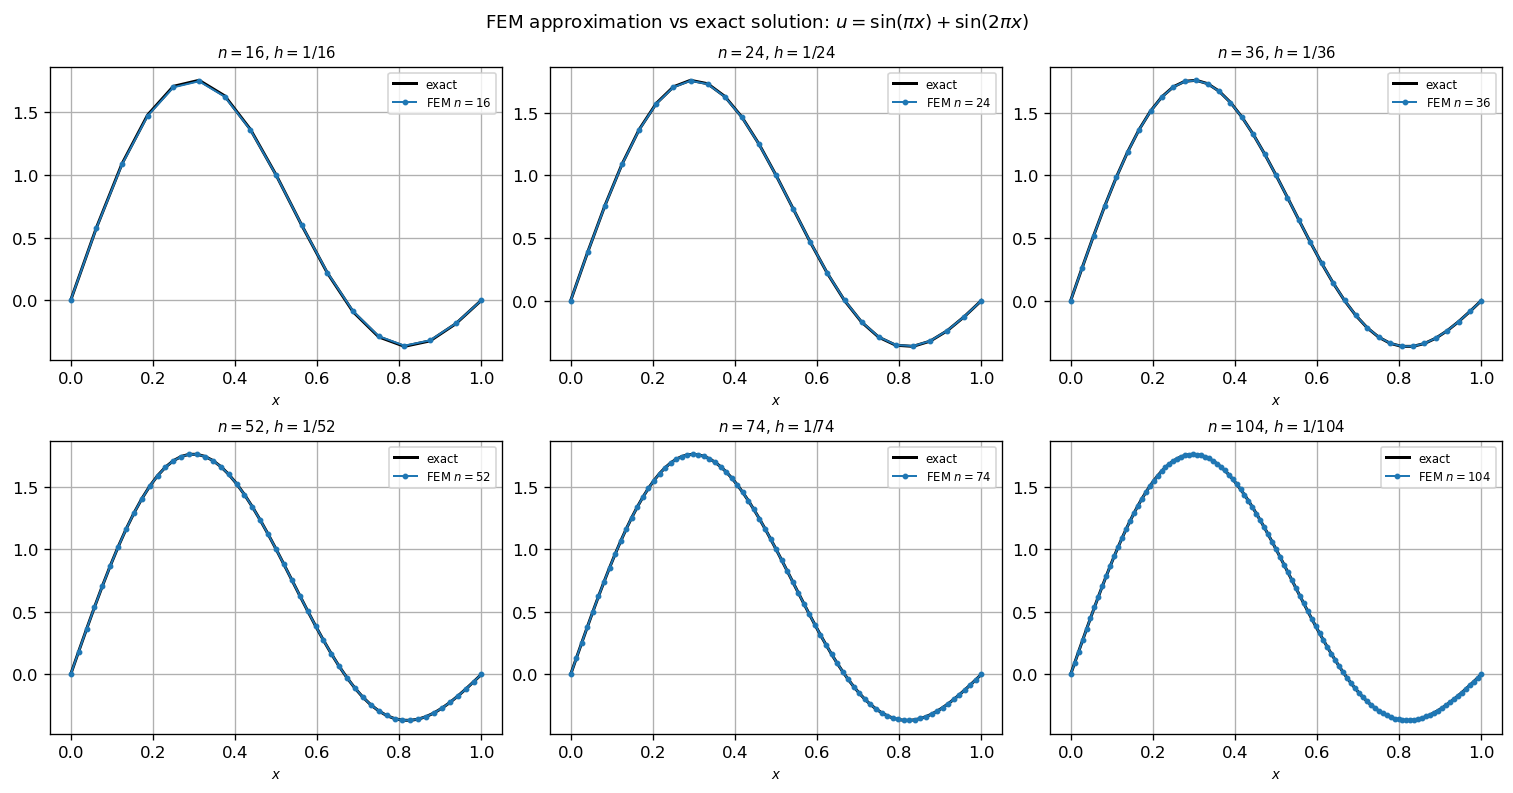

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), constrained_layout=True)
for ax, (nv, (xv, uv)) in zip(axes.ravel(), zip(levels, sol)):
    ax.plot(xv, u_true(xv), "k", lw=1.8, label="exact")
    ax.plot(xv, uv, "o-", ms=2.5, lw=1.2, label=f"FEM $n={nv}$")
    ax.set_title(f"$n={nv}$, $h=1/{nv}$", fontsize=9)
    ax.set_xlabel("$x$", fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle("FEM approximation vs exact solution: $u = \\sin(\\pi x)+\\sin(2\\pi x)$", fontsize=11)
fig.savefig(OUT / "solutions.png", bbox_inches="tight")

## Convergence study

For piecewise-linear FEM the classic error estimate gives
$$
\|u - u_h\|_{L^\infty} \leq C h^2 \|u''\|_{L^\infty},
$$
so the log-log slope of max-error vs $n$ (with $h = 1/n$) should approach $-2$. We plot this below and overlay the reference slope.

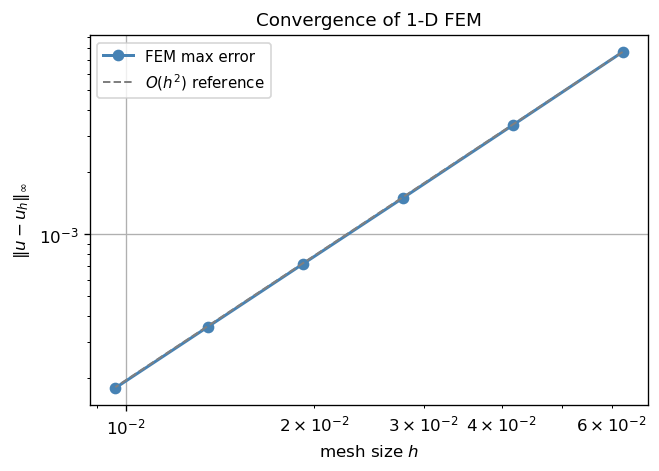

In [4]:
hs = np.array([1 / n for n in levels])

fig_conv, ax_conv = plt.subplots(figsize=(6, 4))
ax_conv.loglog(hs, errs, "o-", lw=1.8, color="steelblue", label="FEM max error")
# Reference O(h^2) line anchored at coarsest mesh
ref = errs[0] * (hs / hs[0]) ** 2
ax_conv.loglog(hs, ref, "--", color="gray", lw=1.2, label="$O(h^2)$ reference")
ax_conv.set_xlabel("mesh size $h$", fontsize=10)
ax_conv.set_ylabel("$\\|u - u_h\\|_\\infty$", fontsize=10)
ax_conv.set_title("Convergence of 1-D FEM", fontsize=11)
ax_conv.legend(fontsize=9)
fig_conv.savefig(OUT / "convergence.png", bbox_inches="tight")

## Combined snippet figure

The snippet below combines the best-resolution FEM solution and the convergence plot into a single representative figure saved as `snippet.png`.

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    fig_s, axes_s = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

    # Left: finest mesh solution
    xf, uf = sol[-1]
    nf = levels[-1]
    axes_s[0].plot(xf, u_true(xf), "k", lw=1.8, label="exact")
    axes_s[0].plot(xf, uf, "o-", ms=2.5, lw=1.2, color="steelblue", label=f"FEM $n={nf}$")
    axes_s[0].set_title(f"Solution at finest mesh ($n={nf}$)", fontsize=10)
    axes_s[0].set_xlabel("$x$")
    axes_s[0].legend(fontsize=9)

    # Right: convergence
    axes_s[1].loglog(hs, errs, "o-", lw=1.8, color="steelblue", label="FEM max error")
    axes_s[1].loglog(hs, ref, "--", color="gray", lw=1.2, label="$O(h^2)$")
    axes_s[1].set_xlabel("mesh size $h$")
    axes_s[1].set_ylabel("$\\|u - u_h\\|_\\infty$")
    axes_s[1].set_title("Convergence", fontsize=10)
    axes_s[1].legend(fontsize=9)

    fig_s.suptitle("Finite Element Method in 1D", fontsize=12)
    fig_s.savefig(OUT / "snippet.png", bbox_inches="tight")
    plt.close(fig_s)
    print(f"Snippet saved to {OUT / 'snippet.png'}")

Snippet saved to python/fem-1d-2d/snippet.png


## Takeaways

- **Weak form:** The variational formulation replaces the strong PDE by an integral identity, enabling natural treatment of boundary conditions and irregular geometry.
- **Assembly:** The global stiffness matrix and load vector are assembled element by element; each element contributes a small local matrix.
- **Convergence:** Piecewise-linear FEM achieves $O(h^2)$ convergence in the maximum norm for smooth solutions, as confirmed by the log-log plot.
- **Multi-frequency RHS:** Using $f = \pi^2\sin(\pi x) + 4\pi^2\sin(2\pi x)$ produces a richer solution with two oscillation modes, illustrating that FEM resolves multiple frequencies simultaneously once the mesh is fine enough.

## Bibliographical Resources

- P. G. Ciarlet, *The Finite Element Method for Elliptic Problems*, North-Holland, 1978.
- C. Johnson, *Numerical Solution of Partial Differential Equations by the Finite Element Method*, Cambridge University Press, 1987.
- S. C. Brenner and L. R. Scott, *The Mathematical Theory of Finite Element Methods*, 3rd ed., Springer, 2008.
- T. J. R. Hughes, *The Finite Element Method: Linear Static and Dynamic Finite Element Analysis*, Dover, 2000.